# Three Body Problem

In orbital mechanics, the Three-body Problem (3BP) is the study of how a mass ($m_{3}$) moves under the influence of two other masses ($m_{1}$ and $m_{2}$). The figure below shows the standard setup for the 3BP.

Unlike the simpler Two Body problem, the Three Body problem does not have a closed form  solution and is generally simplified by assuming the following:

* $m_{3}$ is *restricted* such that $m_{1}>m_{2}>>m_{3}$. This implies that $m_{3}$ is *infinitesimal*, so it cannot impact the motion of $m_{1}$ and $m_{2}$
* The motion of $m_{2}$ around $m_{1}$ is keplerian and *circular*

Now the problem (that is still non linear) is scaled to the **Circular Restricted Three-body Problem (CR3BP)**

<center><img src="Images/threeBody.png" alt="Drawing" style="width: 600px;"/><center>

Note as the position of $m_{3}$ is defined by the vector $\overrightarrow{R_{3}}$. Using Newton’s Law of Gravity, the equation of motion of $m_{3}$ is written as:

$$m_{3}\ddot{\overrightarrow R_3}=-\frac{Gm_{1}m_{3}}{R_{13}^{3}}\overrightarrow R_{13}-\frac{Gm_{1}m_{2}}{R_{23}^{3}}\overrightarrow R_{23}$$

This equation can be generalized by introducing **characteristic quantities** and performing nondimensionalization.

## Nondimensionalizing the equation of motion
Nondimensionalization is a method to take physical dimensions out of a problem and is useful for simplifying mathematical expressions. As first, we define characteristic quantities for mass, length, and time:

- The unit of mass is set to be $m^{*} = m_1+m_2$

- The unit of lenght is set to be the distance between $m_1$ and $m_2$: $l^{*} = R_1+R_2$

- The unit of time is set in such a way the orbit period of $m_1$ and $m_2$ around their center of mass is $2\pi$ (as consequence, the mean motion of the primary bodies is 1):

 $$t^{*} = 2\pi \sqrt[2]{\frac{(l^{*})^{3}}{Gm^{*}}}$$

The only parameter of the system is the **mass parameter**:

$$\mu = \frac{m_{2}}{m_{1} + m_{2}}$$

If we assume that $m_{1} > m_{2}$, then the massess $m_{1}$ and $m_{2}$ are $\mu_{1} = 1 - \mu$ and $\mu_{2} = \mu$

The characteristic quantities are used to nondimentionalize the initial state.

So that we have (for distance, mass and time respectively):

$$r=\frac{R}{l^{*}}$$
$$\mu=\frac{m_{2}}{m^{*}}$$
$$\tau=\frac{t}{t^{*}}$$

<center><img src="Images/threeBodyNd.png" alt="Drawing" style="width: 500px;"/><center>

The Figure above shows the 3-body system as defined in a non-dimensional, rotating reference system.
As example, the dimensional parameters for the Earth-Moon system are here reported:

In [ ]:
from routines import *
PrintCr3bpEarthMoonParameters()

## Integrating the equation of motion

Applying nondimensionalization to the equation of motion, it can be rewritten in scalar form as:

$$\ddot{x} = x+2\dot{y}-\frac{(1-\mu)(x+\mu)}{r_{1}^{3}}-\frac{\mu[x-(1-\mu)]}{r_{2}^{3}}$$
$$\ddot{y} = y-2\dot{x}-\frac{(1-\mu)y}{r_{1}^{3}}-\frac{\mu y}{r_{2}^{3}}$$
$$\ddot{z} = -\frac{(1-\mu)z}{r_{1}^{3}}-\frac{\mu z}{r_{2}^{3}}$$

The nondimensionalization will simplify the equation since $r_{12}=1$ and $\tau=2\pi$ after one complete revolution.

These non-dimensional equations of motion do not have a general analytical solution, but can be numerically integrated to get the motion of $m_{3}$ in the **rotating frame**. Note that for the CR3BP, the primaries will remain stationary in the rotating frame. In order to get an inertial vector from a rotating vector in the CR3BP, we can use the following equation:

$$\begin{bmatrix}
X\\ 
Y\\ 
Z
\end{bmatrix} = \begin{bmatrix}
xcos(t)-ysin(t))\\ 
xsin(t)+ycos(t))\\ 
z
\end{bmatrix}$$

## The equilibrium points
The system equilibrium points, also called the **Lagrange or libration points**, are determined from the above equations for

$$\dot{x}=\ddot{x}=0$$  

$$\dot{y}=\ddot{y}=0$$

$$z=0$$

An object placed at one of the equilibrium points will, if it is not perturbed, remain at that location indefinitely.
The are five points that satisfy the above equations. Two of them can be calculated analytically:

$$L_{4}=\begin{bmatrix}
\frac{1}{2}-\mu, & 
\frac{\sqrt(3)}{2}
\end{bmatrix}$$

$$L_{5}=\begin{bmatrix}
\frac{1}{2}-\mu, & 
-\frac{\sqrt(3)}{2}
\end{bmatrix}$$

$L_{4}$ and $L_{5}$, are called **triangular** or **equilateral** points. The remaining three equilibrium points, i.e., $L_{1}$, $L_{2}$ and $L_{3}$ don't have an analytical solution and must be approximated numerically.


In [ ]:
from routines import *
%matplotlib widget

########################################## INPUT DATA ##########################################################
mu = 0.012150584673413888 # Earth-Moon system
#mu = 3.054200000000000E-6 # Sun-Earth system
################################################################################################################

df = GetLibrationPointsCoord(mu)
PlotLagrangianPoints(df, mu)

## Jacobi Constant

The potential energy (also called pseudopotential) in the CR3BP for nondimensionalized system is written as follows:

 $$U=\frac{1-\mu}{\sqrt{(x+\mu)^{2}+y^{2}+z^{2}}}+\frac{\mu}{\sqrt{(x-1+\mu)^{2}+y^{2}+z^{2}}}+\frac{n^{2}}{2}(x^{2}+y^{2})=\frac{1-\mu}{r_{1}}+\frac{\mu}{r_{2}}+\frac{n^{2}}{2}(x^{2}+y^{2})$$

This equation is composed by three terms:
- The gravitational potential energy due to the position of $m_{3}$ relative to $m_{1}$
- The gravitational potential energy due to the position of $m_{3}$ relative to $m_{2}$
- The potential energy due to the centrifugal force induced by the rotation of the reference frame

Note that $U$ is big when either $r_{1}$ or $r_{2}$ are small or when $x$ and/or $y$ are large enough.

The figure below shows how the potential appears in 3D:

<center><img src="Images/potential.png" alt="Drawing" style="width: 500px;"/><center>
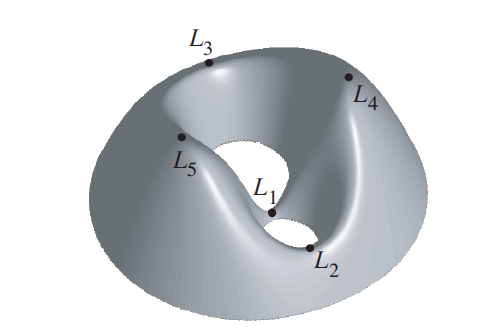

It can be demonstrated that if we subtract the mass-specific kinetic energy from the pseudo potential, we get a constant integral of motion called **Jacoby constant**:

 $$J = 2U-(\dot{x}^{2}+\dot{y}^{2}+\dot{z}^{2})$$

Since $J$ is a constant, the total energy of $m_{3}$ is fixed. It can trade kinetic energy for potential energy and vice versa, but the total energy cannot change. $J$ values can be imagined as an horizontal plane (whose altitude is $J$) intersecating the 3D surface above, that excludes the portions of the 3D surface liyng above the plane.

Consider $m_{3}$ at some location $(x_{1}^{*}, y_{1}^{*})$ such that it has potential energy $U_{1}$. Also assume that the velocity in the rotating frame is zero ($v_{1}^{*}=0$). Then, the Jacobi constant is $J=2U_{1}$, and the mass cannot climb higher out of the potential energy surface. Thus, there is a region of space where the mass cannot access because it doesn't have enough energy. The allowed region is also called *Hill's region*.

<center><img src="Images/realms.png" alt="Drawing" style="width: 600px;"/><center>
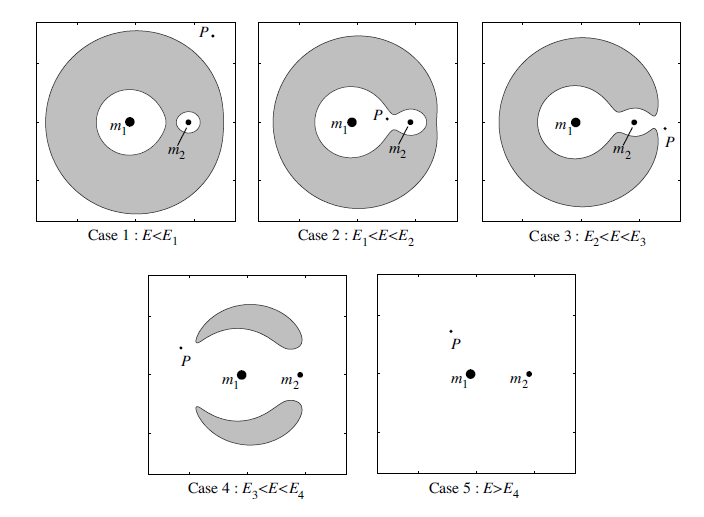

The figure above shows zero velocity curves for five values of the energy. These curves bound the zone (in white) accessible by the particle, P, for a given energy value $E$.

The part of the $x$-$y$ plane which is shaded is inaccessible for a given energy, and known as the forbidden realm. The outermost accessible realm, known as the exterior realm, extends to infinity. In the fifth case the forbidden realmvanishes and motion over the entire x-y plane is possible.

* **Case 1**, $E < E_{1}$: If the energy of the particle is below $E_{1}$, the particle cannot move between the realms around $m_{1}$ and $m_{2}$.


* **Case 2**, $E_{1} < E < E_{2}$: If the energy is just above $E_{1}$, a “neck” between the realms around $m_{1}$ and $m_{2}$ opens up, permitting the particle to move between the two realms. The $L_{1}$ point is in this neck. The particle is still barred from moving between these two realms and the exterior realm extending to infinity.


* **Case 3**, $E_{2} < E < E_{3}$: The particle can move between the vicinity of $m_{1}$ and $m_{2}$ and the exterior realm via a neck around $L_{2}$.


* **Case 4**, $E_{3} < E < E_{4} = E_{5}$: In this case the energy is above $E_{3}$ but below that of $E_{4}$ and $E_{5}$. The particle can pass directly from the vicinity of $m_{1}$ to the exterior realm via a neck around $L_{3}$.


* **Case 5**, $E > E_{4} = E_{5}$: the forbidden realm disappears. Case 5 is where the particle is free tomove in the entire $x$-$y$ plane.

When the energy increases, the JC value decreases and viceversa:
<center><img src="Images/energyJC.png" alt="Drawing" style="width: 1000px;"/><center>

In [ ]:
PlotMultipleZeroVelocityCurve(mu)

The figure above shows the **zero velocity curves**, highliting portions of space where the motion is allowed assuming a specific value of th Jacobi Constant JC. Each libration point has an associated JC value, which is here reported as function of the mass parameter:

In [ ]:
PrintJacobiConstantLibrationPoints(mu)

In the code below, set a JC value to see the Hill's region related to that energy:

In [ ]:
########################################## INPUT DATA ##########################################################
jacobiConstant = 3.172160453579314
################################################################################################################

PlotSingleZeroVelocityCurve(jacobiConstant, mu)

## Integrate and plot

Use the following code snippets to propagate any non-dimensional initial state

In [ ]:
########################################## INPUT DATA ##########################################################
ndInitialState = [0.643, 0.1, 0.54, 0, 0.14, 0] # initial state
tau = 15                                   # integration time. 6.28 is the orbit period of the secondary respect to the primary
################################################################################################################

PlotThreeBodyOrbit(ndInitialState, tau, 1000, mu)

## NASA Periodic Orbits Database

A full, interactive catalog of periodic orbits can be found at this NASA JPS website: https://ssd.jpl.nasa.gov/tools/periodic_orbits.html